# 5. Обучение и подбор гиперпараметров

В этом ноутбуке мы:

1. Обучим все основные модели регрессии с дефолтными параметрами
2. Проведём кросс-валидацию на топ-3 моделях
3. Подберём гиперпараметры (RandomizedSearch + GridSearch)
4. Построим финальный ансамбль `StackingRegressor`
5. Сравним все модели и сохраним лучшую

**Целевая метрика:** MAE в исходных долларах (обратное `expm1` от log-предсказания).

---

## Содержание

1. [Загрузка данных](#section-1)
2. [Функции оценки моделей](#section-2)
3. [Дефолтные модели](#section-3)
4. [Кросс-валидация](#section-4)
5. [Подбор гиперпараметров (RandomizedSearch + GridSearch)](#section-5)
6. [Финальный ансамбль StackingRegressor](#section-6)
7. [Сравнение всех моделей и выбор лучшей](#section-7)
8. [Сохранение финальной модели](#section-8)

<a id='section-1'></a>
## 1. Загрузка данных и библиотек

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.base import clone

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
    print("XGBoost: доступен")
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost: НЕ установлен")

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
    print("CatBoost: доступен")
except ImportError:
    CATBOOST_AVAILABLE = False
    print("CatBoost: НЕ установлен")

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
Path('reports/figures').mkdir(parents=True, exist_ok=True)

XGBoost: доступен
CatBoost: доступен


In [2]:
data_path = Path('data/processed')

X_train = pd.read_csv(data_path / 'X_train.csv', index_col=0)
X_test  = pd.read_csv(data_path / 'X_test.csv',  index_col=0)
y_train = pd.read_csv(data_path / 'y_train.csv', index_col=0).squeeze()
y_test  = pd.read_csv(data_path / 'y_test.csv',  index_col=0).squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

# Проверим пропуски
assert X_train.isnull().sum().sum() == 0, "Найдены пропуски в X_train!"
assert X_test.isnull().sum().sum()  == 0, "Найдены пропуски в X_test!"
print("\nПропусков нет. Данные готовы к обучению.")

# Статистика целевой переменной
y_train_prices = np.expm1(y_train)
print(f"\nСтатистика цен (train, исходная шкала):")
print(f"  Среднее:  ${y_train_prices.mean():,.0f}")
print(f"  Медиана:  ${y_train_prices.median():,.0f}")
print(f"  Мин:      ${y_train_prices.min():,.0f}")
print(f"  Макс:     ${y_train_prices.max():,.0f}")

X_train: (182152, 50)
X_test:  (78106, 50)
y_train: (182152,)
y_test:  (78106,)

Пропусков нет. Данные готовы к обучению.

Статистика цен (train, исходная шкала):
  Среднее:  $17,779
  Медиана:  $13,995
  Мин:      $500
  Макс:     $100,000


<a id='section-2'></a>
## 2. Функции оценки моделей

Все метрики вычисляются в **исходной шкале (долларах)** через обратное преобразование `expm1`.

In [3]:
def evaluate(name, model, X, y_log_true, verbose=True):
    """Вычисляет MAE, RMSE, R² и MAPE в исходных долларах."""
    y_pred_log = model.predict(X)
    y_pred     = np.expm1(y_pred_log)
    y_true     = np.expm1(y_log_true)

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    if verbose:
        print(f"\n{'='*40}")
        print(f"{name}")
        print(f"{'='*40}")
        print(f"  MAE:  ${mae:>10,.2f}")
        print(f"  RMSE: ${rmse:>10,.2f}")
        print(f"  R²:    {r2:>10.4f}")
        print(f"  MAPE:  {mape:>10.2f}%")

    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}


def compare_models(results_list):
    """Сводная таблица метрик, отсортированная по MAE."""
    df = pd.DataFrame(results_list)
    df['MAE']  = df['MAE'].round(2)
    df['RMSE'] = df['RMSE'].round(2)
    df['R2']   = df['R2'].round(4)
    df['MAPE'] = df['MAPE'].round(2)
    return df.sort_values('MAE').reset_index(drop=True)


print("Функции оценки моделей определены.")

Функции оценки моделей определены.


<a id='section-3'></a>
## 3. Обучение моделей с дефолтными параметрами

Обучаем все модели с параметрами по умолчанию для получения baseline-метрик.

| Модель | Тип | Особенности |
|---|---|---|
| DecisionTree | Одно дерево | Быстро переобучается |
| RandomForest | Бэггинг деревьев | Устойчив, хорошо обобщает |
| GradientBoosting | Бустинг | Высокое качество, медленнее |
| XGBoost | Оптимизированный бустинг | Быстрый, часто лучший |
| CatBoost | Бустинг для категориальных | Эффективен на OHE-данных |

In [4]:
models = {
    'DecisionTree':     DecisionTreeRegressor(random_state=42),
    'RandomForest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

if XGB_AVAILABLE:
    models['XGBoost'] = XGBRegressor(
        n_estimators=100, random_state=42, n_jobs=-1,
        verbosity=0, eval_metric='mae'
    )

if CATBOOST_AVAILABLE:
    models['CatBoost'] = CatBoostRegressor(
        iterations=100, verbose=0, random_state=42, thread_count=-1
    )

print(f"Подготовлено {len(models)} моделей:")
for name in models:
    print(f"  - {name}")

Подготовлено 5 моделей:
  - DecisionTree
  - RandomForest
  - GradientBoosting
  - XGBoost
  - CatBoost


In [5]:
trained_models = {}
default_results = []

for name, model in models.items():
    print(f"Обучение {name}...", end=' ', flush=True)
    model.fit(X_train, y_train)
    trained_models[name] = model
    metrics = evaluate(name, model, X_test, y_test)
    default_results.append(metrics)

default_df = compare_models(default_results)
print("\n" + "=" * 60)
print("Сводная таблица (дефолтные параметры, тест):")
print(default_df.to_string(index=False))

Обучение DecisionTree... 
DecisionTree
  MAE:  $  3,897.56
  RMSE: $  7,583.96
  R²:        0.7128
  MAPE:       54.80%
Обучение RandomForest... 
RandomForest
  MAE:  $  3,014.24
  RMSE: $  5,946.70
  R²:        0.8234
  MAPE:       38.01%
Обучение GradientBoosting... 
GradientBoosting
  MAE:  $  4,403.18
  RMSE: $  7,576.97
  R²:        0.7133
  MAPE:       52.27%
Обучение XGBoost... 
XGBoost
  MAE:  $  3,653.63
  RMSE: $  6,440.96
  R²:        0.7928
  MAPE:       40.32%
Обучение CatBoost... 
CatBoost
  MAE:  $  3,780.56
  RMSE: $  6,559.59
  R²:        0.7851
  MAPE:       41.68%

Сводная таблица (дефолтные параметры, тест):
           Model     MAE    RMSE     R2  MAPE
    RandomForest 3014.24 5946.70 0.8234 38.01
         XGBoost 3653.63 6440.96 0.7928 40.32
        CatBoost 3780.56 6559.59 0.7851 41.68
    DecisionTree 3897.56 7583.96 0.7128 54.80
GradientBoosting 4403.18 7576.97 0.7133 52.27


C:\Users\Alex\AppData\Local\Temp\ipykernel_15956\3399082870.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=default_df, x='MAE', y='Model', palette='viridis', ax=axes[0])
C:\Users\Alex\AppData\Local\Temp\ipykernel_15956\3399082870.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=default_df, x='R2', y='Model', palette='magma', ax=axes[1])


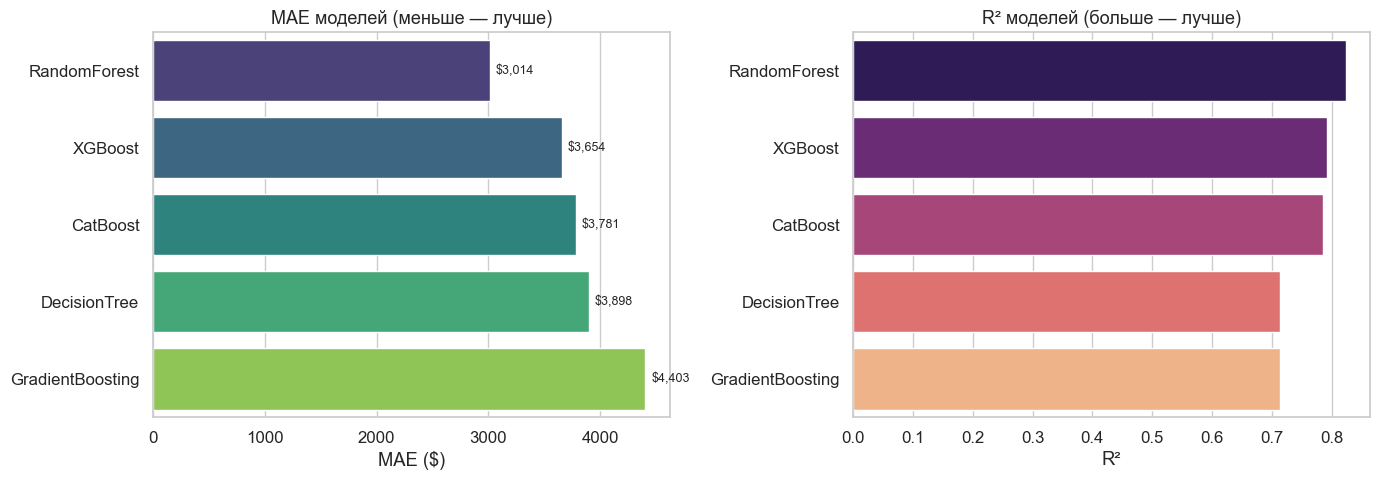

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=default_df, x='MAE', y='Model', palette='viridis', ax=axes[0])
axes[0].set_title('MAE моделей (меньше — лучше)', fontsize=13)
axes[0].set_xlabel('MAE ($)')
axes[0].set_ylabel('')
for i, row in default_df.iterrows():
    axes[0].text(row['MAE'] + 50, i, f"${row['MAE']:,.0f}", va='center', fontsize=9)

sns.barplot(data=default_df, x='R2', y='Model', palette='magma', ax=axes[1])
axes[1].set_title('R² моделей (больше — лучше)', fontsize=13)
axes[1].set_xlabel('R²')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../reports/figures/model_comparison_default.png', dpi=150, bbox_inches='tight')
plt.show()

<a id='section-4'></a>
## 4. Кросс-валидация

5-fold кросс-валидация на тренировочных данных для топ-3 моделей.
CV позволяет оценить стабильность модели и сравнить её без переобучения под тест.

In [ ]:
top3_names = default_df.head(3)['Model'].tolist()
print(f"Топ-3 модели для кросс-валидации: {top3_names}")

cv_results = {}

for name in top3_names:
    model = models[name]
    print(f"\nCV для {name}...")
    scores = cross_val_score(
        clone(model), X_train, y_train,
        cv=5, scoring='neg_mean_absolute_error', n_jobs=1
    )
    # scores в log-пространстве, переводим приближённо (для сравнения используем log-MAE)
    mae_log_mean = -scores.mean()
    mae_log_std  = scores.std()
    cv_results[name] = (mae_log_mean, mae_log_std)
    print(f"  CV MAE (log-scale): {mae_log_mean:.4f} ± {mae_log_std:.4f}")

best_cv_model = min(cv_results, key=lambda k: cv_results[k][0])
print(f"\nНаиболее стабильная модель: {best_cv_model}")

Топ-3 модели для кросс-валидации: ['RandomForest', 'XGBoost', 'CatBoost']

CV для RandomForest...
  CV MAE (log-scale): 0.2383 ± 0.0011

CV для XGBoost...
  CV MAE (log-scale): 0.2550 ± 0.0016

CV для CatBoost...
  CV MAE (log-scale): 0.2617 ± 0.0019

Наиболее стабильная модель: RandomForest


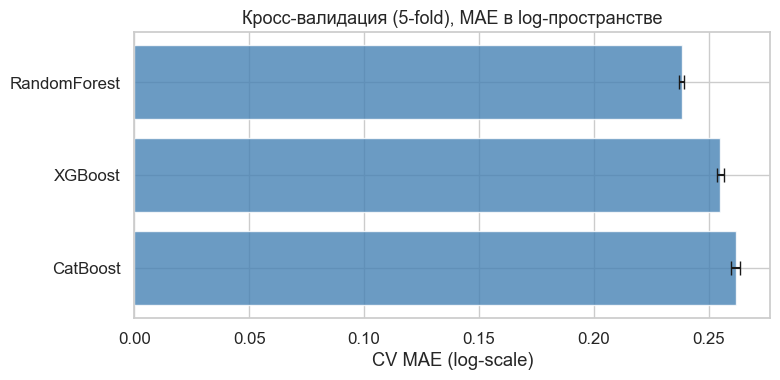

In [9]:
cv_df = pd.DataFrame([
    {'Model': name, 'CV_MAE_log': v[0], 'CV_std': v[1]}
    for name, v in cv_results.items()
]).sort_values('CV_MAE_log')

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(cv_df['Model'], cv_df['CV_MAE_log'],
        xerr=cv_df['CV_std'], capsize=5,
        color='steelblue', alpha=0.8, edgecolor='white')
ax.set_title('Кросс-валидация (5-fold), MAE в log-пространстве', fontsize=13)
ax.set_xlabel('CV MAE (log-scale)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/cv_comparison.png', dpi=150)
plt.show()

<a id='section-5'></a>
## 5. Подбор гиперпараметров

**Стратегия двухэтапного поиска:**
1. **RandomizedSearchCV** — грубый поиск по широкому пространству (20 итераций)
2. **GridSearchCV** — точный поиск в окрестности найденного оптимума

Тюним топ-2 модели по результатам CV.

In [10]:
param_distributions = {
    'RandomForest': {
        'n_estimators':      [100, 200, 300, 400],
        'max_depth':         [None, 15, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf':  [1, 2, 4],
        'max_features':      ['sqrt', 'log2'],
    },
    'GradientBoosting': {
        'n_estimators':  [100, 200, 300, 500],
        'max_depth':     [3, 4, 5, 6],
        'learning_rate': [0.03, 0.05, 0.1, 0.15],
        'subsample':     [0.7, 0.8, 0.9, 1.0],
    },
    'XGBoost': {
        'n_estimators':     [100, 200, 300, 500],
        'max_depth':        [3, 4, 5, 6, 7],
        'learning_rate':    [0.03, 0.05, 0.1, 0.15],
        'subsample':        [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    },
    'CatBoost': {
        'iterations':    [100, 200, 300, 400],
        'depth':         [4, 6, 8],
        'learning_rate': [0.03, 0.05, 0.1],
        'l2_leaf_reg':   [1, 3, 5, 7],
    },
    'DecisionTree': {
        'max_depth':         [5, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf':  [1, 2, 4, 8],
    }
}

top2_names = cv_df.head(2)['Model'].tolist()
print(f"Тюнинг моделей: {top2_names}")

Тюнинг моделей: ['RandomForest', 'XGBoost']


In [12]:
tuned_models   = {}
best_params_dict = {}

for name in top2_names:
    print(f"\n{'='*50}")
    print(f"RandomizedSearchCV для {name}")
    print(f"{'='*50}")

    base_model = clone(models[name])
    param_dist = param_distributions.get(name, {})

    if not param_dist:
        print(f"  Нет сетки параметров, пропускаем.")
        tuned_models[name] = trained_models[name]
        continue

    random_search = RandomizedSearchCV(
        base_model, param_dist,
        n_iter=5, cv=5,
        scoring='neg_mean_absolute_error',
        n_jobs=1, random_state=42,
        refit=True
    )
    random_search.fit(X_train, y_train)

    best_params_dict[name] = random_search.best_params_
    best_mae = -random_search.best_score_
    print(f"  Лучшие параметры: {random_search.best_params_}")
    print(f"  CV MAE (log-scale): {best_mae:.4f}")

    tuned_models[f'{name}_coarse'] = random_search.best_estimator_


RandomizedSearchCV для RandomForest
  Лучшие параметры: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
  CV MAE (log-scale): 0.2384

RandomizedSearchCV для XGBoost
  Лучшие параметры: {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
  CV MAE (log-scale): 0.2444


In [15]:
def narrow_grid(param_dist, best_params):
    """Строит уточнённую сетку вокруг лучших параметров из RandomizedSearch."""
    narrow = {}
    for param, values in param_dist.items():
        best_val = best_params.get(param)
        if best_val is None or not isinstance(values, list):
            narrow[param] = values if isinstance(values, list) else [best_val]
            continue
        if best_val in values:
            idx = values.index(best_val)
            narrow[param] = values[max(0, idx - 1): idx + 2]
        else:
            narrow[param] = [best_val]
    return narrow


for name in top2_names:
    coarse_key = f'{name}_coarse'
    if coarse_key not in tuned_models:
        continue

    print(f"\n{'='*50}")
    print(f"GridSearchCV (точный) для {name}")
    print(f"{'='*50}")

    coarse_best = tuned_models[coarse_key]
    param_dist  = param_distributions.get(name, {})
    narrow      = narrow_grid(param_dist, best_params_dict[name])

    print(f"  Уточнённая сетка: {narrow}")

    from sklearn.model_selection import ShuffleSplit

    # Обучаем модель всего 1 раз на случайной валидационной выборке
    # вместо 5-кратного тяжелого перебора.
    single_split_cv = ShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

    grid_search = GridSearchCV(
        clone(coarse_best), narrow,
        cv=single_split_cv,
        scoring='neg_mean_absolute_error',
        n_jobs=1, 
        refit=True
    )
    grid_search.fit(X_train, y_train)

    best_mae = -grid_search.best_score_
    print(f"  Лучшие параметры: {grid_search.best_params_}")
    print(f"  CV MAE (log-scale): {best_mae:.4f}")

    tuned_models[name] = grid_search.best_estimator_


GridSearchCV (точный) для RandomForest
  Уточнённая сетка: {'n_estimators': [200, 300, 400], 'max_depth': [None, 15, 20, 30], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2], 'max_features': ['sqrt', 'log2']}


MemoryError: could not allocate 16777216 bytes

In [ ]:
# Оцениваем тюненные модели на тесте
tuning_results = []

default_mae_map = {row['Model']: row['MAE'] for _, row in default_df.iterrows()}

for name in top2_names:
    if name not in tuned_models:
        continue
    metrics = evaluate(f"{name} (tuned)", tuned_models[name], X_test, y_test)
    tuning_results.append(metrics)

# Таблица сравнения до/после тюнинга
print("\n" + "="*60)
print("Эффект подбора гиперпараметров:")
print("="*60)
for name in top2_names:
    if name not in tuned_models:
        continue
    default_mae = default_mae_map.get(name, float('nan'))
    tuned_metrics = evaluate(name, tuned_models[name], X_test, y_test, verbose=False)
    tuned_mae = tuned_metrics['MAE']
    improvement = (default_mae - tuned_mae) / default_mae * 100
    print(f"  {name}: ${default_mae:,.0f} → ${tuned_mae:,.0f} ({improvement:+.1f}%)")

In [ ]:
comparison_rows = []
for name in top2_names:
    if name not in tuned_models:
        continue
    default_mae = default_mae_map.get(name, float('nan'))
    tuned_mae   = evaluate(name, tuned_models[name], X_test, y_test, verbose=False)['MAE']
    comparison_rows.append({'Model': name, 'Default': default_mae, 'Tuned': tuned_mae})

if comparison_rows:
    comp_df = pd.DataFrame(comparison_rows)
    x = np.arange(len(comp_df))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    bars1 = ax.bar(x - width/2, comp_df['Default'], width, label='Default',  color='#1f77b4', alpha=0.85)
    bars2 = ax.bar(x + width/2, comp_df['Tuned'],   width, label='Tuned',    color='#2ca02c', alpha=0.85)

    ax.set_ylabel('MAE ($)')
    ax.set_title('MAE до и после подбора гиперпараметров', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(comp_df['Model'])
    ax.legend()
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    plt.tight_layout()
    plt.savefig('../reports/figures/tuning_comparison.png', dpi=150)
    plt.show()

<a id='section-6'></a>
## 6. Финальный ансамбль: StackingRegressor

**Идея:** объединяем предсказания нескольких разнообразных базовых моделей (уровень 0) через мета-модель (уровень 1).

- **Уровень 0 (Base Estimators):** лучшие тюненные модели
- **Уровень 1 (Meta Estimator):** Ridge — линейная комбинация предсказаний базовых моделей

Stacking автоматически определяет оптимальные веса для каждой базовой модели.

In [ ]:
# Собираем базовые модели для стекинга
stack_estimators = []

# Приоритет: тюненные версии, затем дефолтные
for name in ['RandomForest', 'XGBoost', 'CatBoost', 'GradientBoosting']:
    if name in tuned_models:
        stack_estimators.append((name, clone(tuned_models[name])))
    elif name in trained_models:
        stack_estimators.append((name, clone(trained_models[name])))

if len(stack_estimators) < 2:
    print("Недостаточно моделей для стекинга, добавляем дефолтные...")
    for name, model in trained_models.items():
        if name not in [e[0] for e in stack_estimators] and name != 'DecisionTree':
            stack_estimators.append((name, clone(model)))

print(f"Базовые модели стекинга ({len(stack_estimators)}):")
for name, _ in stack_estimators:
    print(f"  - {name}")

# Мета-модель: Ridge регрессия
meta_model = Ridge(alpha=1.0)

stacking = StackingRegressor(
    estimators=stack_estimators,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1,
    passthrough=False  # мета-модель видит только out-of-fold предсказания
)

print("\nОбучение StackingRegressor (это займёт время)...")
stacking.fit(X_train, y_train)

metrics_stack = evaluate('StackingRegressor', stacking, X_test, y_test)
tuned_models['StackingRegressor'] = stacking

In [ ]:
# Веса мета-модели (Ridge коэффициенты)
meta_coefs = stacking.final_estimator_.coef_
estimator_names = [name for name, _ in stack_estimators]

meta_df = pd.DataFrame({
    'Model': estimator_names,
    'Weight': meta_coefs
}).sort_values('Weight', ascending=False)

print("Веса мета-модели Ridge (вклад каждой базовой модели):")
print(meta_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['green' if w >= 0 else 'red' for w in meta_df['Weight']]
ax.barh(meta_df['Model'], meta_df['Weight'], color=colors, alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Веса базовых моделей в StackingRegressor', fontsize=13)
ax.set_xlabel('Коэффициент Ridge')
plt.tight_layout()
plt.savefig('../reports/figures/stacking_weights.png', dpi=150)
plt.show()

<a id='section-7'></a>
## 7. Финальное сравнение всех моделей

In [ ]:
all_results = []

# Дефолтные модели
for name, model in trained_models.items():
    m = evaluate(name, model, X_test, y_test, verbose=False)
    all_results.append(m)

# Тюненные модели
for name in top2_names:
    if name in tuned_models:
        m = evaluate(f'{name} (tuned)', tuned_models[name], X_test, y_test, verbose=False)
        all_results.append(m)

# Ансамбль
m = evaluate('StackingRegressor', tuned_models['StackingRegressor'], X_test, y_test, verbose=False)
all_results.append(m)

final_df = compare_models(all_results)

print("\n" + "="*65)
print("ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ (тест)")
print("="*65)
print(final_df.to_string(index=False))

In [ ]:
# Цвет для StackingRegressor — выделим его
palette = ['gold' if 'Stacking' in row['Model'] else
           'steelblue' if '(tuned)' in row['Model'] else 'lightsteelblue'
           for _, row in final_df.iterrows()]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(final_df['Model'], final_df['MAE'],
               color=palette, edgecolor='white', height=0.7)

for bar, mae in zip(bars, final_df['MAE']):
    ax.text(mae + 100, bar.get_y() + bar.get_height()/2,
            f'${mae:,.0f}', va='center', fontsize=9)

ax.set_xlabel('MAE ($)', fontsize=12)
ax.set_title('Сравнение моделей по MAE (тест)', fontsize=14)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='gold',           label='Ансамбль (Stacking)'),
    Patch(facecolor='steelblue',      label='Тюненные модели'),
    Patch(facecolor='lightsteelblue', label='Дефолтные модели'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../reports/figures/final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

<a id='section-8'></a>
## 8. Сохранение финальной модели

In [ ]:
best_row   = final_df.iloc[0]
best_name  = best_row['Model']

# Получаем лучшую модель
if best_name in tuned_models:
    best_model = tuned_models[best_name]
elif best_name in trained_models:
    best_model = trained_models[best_name]
else:
    # Имя может содержать "(tuned)" — ищем базовое имя
    base_name = best_name.replace(' (tuned)', '')
    best_model = tuned_models.get(base_name) or trained_models.get(base_name)

models_path = Path('../models')
models_path.mkdir(parents=True, exist_ok=True)

joblib.dump(best_model, models_path / 'final_model.pkl')
print(f"Модель '{best_name}' сохранена → models/final_model.pkl")

# Сохраняем список признаков
feature_names = list(X_train.columns)
joblib.dump(feature_names, models_path / 'feature_names.pkl')
print(f"Список признаков сохранён → models/feature_names.pkl")

In [ ]:
best_row = final_df.iloc[0]

# Сравниваем с baseline (DummyRegressor median ≈ std целевой переменной)
dummy_mae = np.expm1(y_train).std()
improvement_vs_dummy = (dummy_mae - best_row['MAE']) / dummy_mae * 100

# Сравниваем с лучшей дефолтной моделью
best_default_mae = default_df.iloc[0]['MAE']
improvement_vs_default = (best_default_mae - best_row['MAE']) / best_default_mae * 100

print("\n" + "="*60)
print("ИТОГОВЫЙ ВЫВОД")
print("="*60)
print(f"\n  Лучшая модель:  {best_row['Model']}")
print(f"  MAE:   ${best_row['MAE']:>10,.2f}")
print(f"  RMSE:  ${best_row['RMSE']:>10,.2f}")
print(f"  R²:     {best_row['R2']:>10.4f}")
print(f"  MAPE:   {best_row['MAPE']:>10.2f}%")
print(f"\n  Улучшение vs дефолтная лучшая: +{improvement_vs_default:.1f}%")
print(f"  Улучшение vs dummy baseline:    +{improvement_vs_dummy:.1f}%")
print("="*60)
print("\nГотово! Переходим к анализу ошибок (06_error_analysis.ipynb)")